<a href="https://colab.research.google.com/github/SruthiGS-Gito/Exit_Exam/blob/main/MUDRA_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BHARATANATYAM MUDRA RECOGNITION PREDICTION

## LIBRARIES

In [12]:
from google.colab import drive

import os
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


import cv2
from pathlib import Path
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0, ResNet50
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score)
import pickle
import json

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version: 2.20.0
GPU Available: False


## LOAD DATASET

In [14]:
dataset_root_path = '/content/drive/My Drive/AI ML/ICT_AI_ML/student_manager/data'

print("Dataset root set to:", dataset_root_path)
print("\nClasses found:", sorted(os.listdir(dataset_root_path)))

# Verifying that the expected mudra folders exist
expected_classes = ['Musti', 'Pataka', 'Sikhara', 'Simhamukha', 'Trisula']
found_classes = [d for d in os.listdir(dataset_root_path) if os.path.isdir(os.path.join(dataset_root_path, d)) and d in expected_classes]

if set(expected_classes) == set(found_classes):
    print("All expected mudra class folders are present.")
else:
    print("Warning : Not all expected mudra class folders were found or extra folders exist.")
    print("Expected :", expected_classes)
    print("Found :", found_classes)

Dataset root set to: /content/drive/My Drive/AI ML/ICT_AI_ML/student_manager/data

Classes found: ['AIML_Computer_Vision_Case_Study.pdf', 'Amazon_Consumer_Reviews.ipynb', 'Dog.webp', 'Ganpati_Bappa.jpg', 'House_Pricing.csv', 'Jonas_Brother_2000s.jpg', 'Mall_Customers.csv', 'Musti', 'OnlineNewsPopularity.csv', 'Parallel_Project_1_ADVANCED_Web_App.ipynb', 'Pataka', 'Sikhara', 'Simhamukha', 'Trisula', 'adult_dataset.csv', 'auto-mpg.csv', 'beer-servings.csv', 'churn-data-v2.csv', 'employee_salary_regression_dataset.csv', 'heart_disease.csv', 'news_popularity_prediction.py', 'obama.jpg', 'secondary+mushroom+dataset.zip', 'spam.xlsx', 'student_performance_demo.csv', 'test', 'train', 'wallpaper.webp']
All expected mudra class folders are present.


## DATA ANALYSIS

In [18]:
IMG_WIDTH, IMG_HEIGHT = 128, 128
BATCH_SIZE = 32

datagen = ImageDataGenerator(rescale=1./255)

# Load images from directory
dataset = datagen.flow_from_directory(
    dataset_root_path,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

# Get class names and their mapping
class_names = list(dataset.class_indices.keys())
class_indices = dataset.class_indices

print(f"Found {dataset.samples} images belonging to {dataset.num_classes} classes.")
print(f"Class names: {class_names}")
print(f"Class indices: {class_indices}")

Found 2152 images belonging to 7 classes.
Found 2152 images belonging to 7 classes.
Class names: ['Musti', 'Pataka', 'Sikhara', 'Simhamukha', 'Trisula', 'test', 'train']
Class indices: {'Musti': 0, 'Pataka': 1, 'Sikhara': 2, 'Simhamukha': 3, 'Trisula': 4, 'test': 5, 'train': 6}


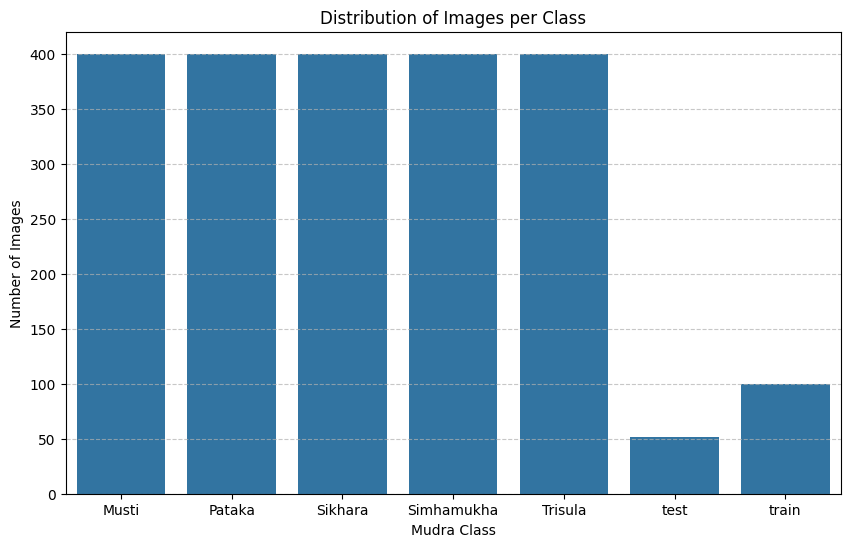

,Class,Count
0,Musti,400
1,Pataka,400
2,Sikhara,400
3,Simhamukha,400
4,Trisula,400
5,test,52
6,train,100


The dataset appears to be imbalanced.
Minimum images per class: 52
Maximum images per class: 400

Impact of Imbalance on Learning:
An imbalanced dataset can lead to models that perform poorly on minority classes because the model learns less about them. It might achieve high overall accuracy by primarily predicting the majority class, but fail to generalize well to less represented classes. This can lead to biased predictions, especially in real-world scenarios where minority classes might be critical. Techniques like oversampling minority classes, undersampling majority classes, using class weights, or employing specific evaluation metrics (like F1-score, precision, recall) are often necessary to mitigate these effects.


In [19]:
# Count images per class
class_counts = {class_name: 0 for class_name in class_names}
for label_idx in dataset.labels:
    class_name = class_names[label_idx]
    class_counts[class_name] += 1

class_counts_df = pd.DataFrame(class_counts.items(), columns=['Class', 'Count'])

plt.figure(figsize=(10, 6))
sns.barplot(x='Class', y='Count', data=class_counts_df)
plt.title('Distribution of Images per Class')
plt.xlabel('Mudra Class')
plt.ylabel('Number of Images')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

display(class_counts_df)

# Check for balance
is_balanced = all(count == class_counts_df['Count'].iloc[0] for count in class_counts_df['Count'])
if is_balanced:
    print("The dataset appears to be balanced.")
else:
    print("The dataset appears to be imbalanced.")
    min_count = class_counts_df['Count'].min()
    max_count = class_counts_df['Count'].max()
    print(f"Minimum images per class: {min_count}")
    print(f"Maximum images per class: {max_count}")

In [42]:
all_image_paths = []
all_image_labels = []

mudra_classes = ['Musti', 'Pataka', 'Sikhara', 'Simhamukha', 'Trisula']

print(f"Collecting images for the following mudra classes: {mudra_classes}")

for class_name in mudra_classes:
    class_path = os.path.join(dataset_root_path, class_name)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            if os.path.isfile(img_path):
                all_image_paths.append(img_path)
                all_image_labels.append(class_name)

data_df = pd.DataFrame({'Path': all_image_paths, 'Label': all_image_labels})

print(f"Total images collected: {len(data_df)}")
print("Initial class distribution (corrected):")
display(data_df['Label'].value_counts().sort_index().to_frame())

Total images collected: 2000
Initial class distribution (corrected):


,count
Label,
Musti,400
Pataka,400
Sikhara,400
Simhamukha,400
Trisula,400


In [43]:
all_image_paths = []
all_image_labels = []

mudra_classes = ['Musti', 'Pataka', 'Sikhara', 'Simhamukha', 'Trisula']

print(f"Collecting images for the following mudra classes: {mudra_classes}")

for class_name in mudra_classes:
    class_path = os.path.join(dataset_root_path, class_name)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            if os.path.isfile(img_path):
                all_image_paths.append(img_path)
                all_image_labels.append(class_name)

data_df = pd.DataFrame({'Path': all_image_paths, 'Label': all_image_labels})

print(f"Total images collected: {len(data_df)}")
print("Initial class distribution (corrected):")
display(data_df['Label'].value_counts().sort_index().to_frame())

Total images collected: 2000
Initial class distribution (corrected):


,count
Label,
Musti,400
Pataka,400
Sikhara,400
Simhamukha,400
Trisula,400


In [44]:
X = data_df['Path']
y = data_df['Label']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size = 0.3, random_state = 42, stratify = y)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size = 0.5, random_state = 42, stratify = y_temp)

train_df = pd.DataFrame({'Path': X_train, 'Label': y_train})
val_df = pd.DataFrame({'Path': X_val, 'Label': y_val})
test_df = pd.DataFrame({'Path': X_test, 'Label': y_test})

print("Dataset split complete:")
print(f"Training set size: {len(train_df)}")
print(f"Validation set size: {len(val_df)}")
print(f"Test set size: {len(test_df)}")

print("Training set class distribution:")
display(train_df['Label'].value_counts().sort_index().to_frame())

print("Validation set class distribution:")
display(val_df['Label'].value_counts().sort_index().to_frame())

print("Test set class distribution:")
display(test_df['Label'].value_counts().sort_index().to_frame())

Dataset split complete:
Training set size: 1400
Validation set size: 300
Test set size: 300
Training set class distribution:


,count
Label,
Musti,280
Pataka,280
Sikhara,280
Simhamukha,280
Trisula,280


Validation set class distribution:


,count
Label,
Musti,60
Pataka,60
Sikhara,60
Simhamukha,60
Trisula,60


Test set class distribution:


,count
Label,
Musti,60
Pataka,60
Sikhara,60
Simhamukha,60
Trisula,60


In [45]:
train_datagen = ImageDataGenerator(rescale = 1./255)
val_datagen = ImageDataGenerator(rescale = 1./255)
test_datagen = ImageDataGenerator(rescale = 1./255)

train_generator = train_datagen.flow_from_dataframe(
    dataframe = train_df,
    x_col = 'Path',
    y_col = 'Label',
    target_size = (IMG_WIDTH, IMG_HEIGHT),
    batch_size = BATCH_SIZE,
    class_mode = 'categorical',
    shuffle = True,
    seed = 42
)

validation_generator = val_datagen.flow_from_dataframe(
    dataframe = val_df,
    x_col = 'Path',
    y_col = 'Label',
    target_size = (IMG_WIDTH, IMG_HEIGHT),
    batch_size = BATCH_SIZE,
    class_mode = 'categorical',
    shuffle = False,
    seed = 42
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe = test_df,
    x_col = 'Path',
    y_col = 'Label',
    target_size = (IMG_WIDTH, IMG_HEIGHT),
    batch_size = BATCH_SIZE,
    class_mode = 'categorical',
    shuffle = False,
    seed = 42
)

print(f"Train generator found {train_generator.samples} images belonging to {len(train_generator.class_indices)} classes.")
print(f"Validation generator found {validation_generator.samples} images belonging to {len(validation_generator.class_indices)} classes.")
print(f"Test generator found {test_generator.samples} images belonging to {len(test_generator.class_indices)} classes.")

Found 1400 validated image filenames belonging to 5 classes.
Found 300 validated image filenames belonging to 5 classes.
Found 300 validated image filenames belonging to 5 classes.
Train generator found 1400 images belonging to 5 classes.
Validation generator found 300 images belonging to 5 classes.
Test generator found 300 images belonging to 5 classes.


## PREPROCESSING & AUGMENTATION : Augmentation Pipeline & Visualize Augmented Samples

In [46]:
print("Re-initializing image data generators with augmentation for training data...")

train_datagen_augmented = ImageDataGenerator(
    rescale = 1./255,
    rotation_range = 20,
    width_shift_range = 0.2,
    height_shift_range = 0.2,
    shear_range = 0.2,
    zoom_range = 0.2,
    horizontal_flip = True,
    fill_mode = 'nearest'
)

val_datagen = ImageDataGenerator(rescale = 1./255)
test_datagen = ImageDataGenerator(rescale = 1./255)

train_generator_augmented = train_datagen_augmented.flow_from_dataframe(
    dataframe = train_df,
    x_col = 'Path',
    y_col = 'Label',
    target_size = (IMG_WIDTH, IMG_HEIGHT),
    batch_size = BATCH_SIZE,
    class_mode = 'categorical',
    shuffle = True,
    seed = 42
)

validation_generator = val_datagen.flow_from_dataframe(
    dataframe = val_df,
    x_col = 'Path',
    y_col = 'Label',
    target_size = (IMG_WIDTH, IMG_HEIGHT),
    batch_size = BATCH_SIZE,
    class_mode = 'categorical',
    shuffle = False,
    seed = 42
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe = test_df,
    x_col = 'Path',
    y_col = 'Label',
    target_size = (IMG_WIDTH, IMG_HEIGHT),
    batch_size = BATCH_SIZE,
    class_mode = 'categorical',
    shuffle = False,
    seed = 42
)

print(f"Train generator (augmented) found {train_generator_augmented.samples} images belonging to {len(train_generator_augmented.class_indices)} classes.")
print(f"Validation generator found {validation_generator.samples} images belonging to {len(validation_generator.class_indices)} classes.")
print(f"Test generator found {test_generator.samples} images belonging to {len(test_generator.class_indices)} classes.")

Re-initializing image data generators with augmentation for training data...
Found 1400 validated image filenames belonging to 5 classes.
Found 300 validated image filenames belonging to 5 classes.
Found 300 validated image filenames belonging to 5 classes.
Train generator (augmented) found 1400 images belonging to 5 classes.
Validation generator found 300 images belonging to 5 classes.
Test generator found 300 images belonging to 5 classes.


### Visualizing Augmented Samples

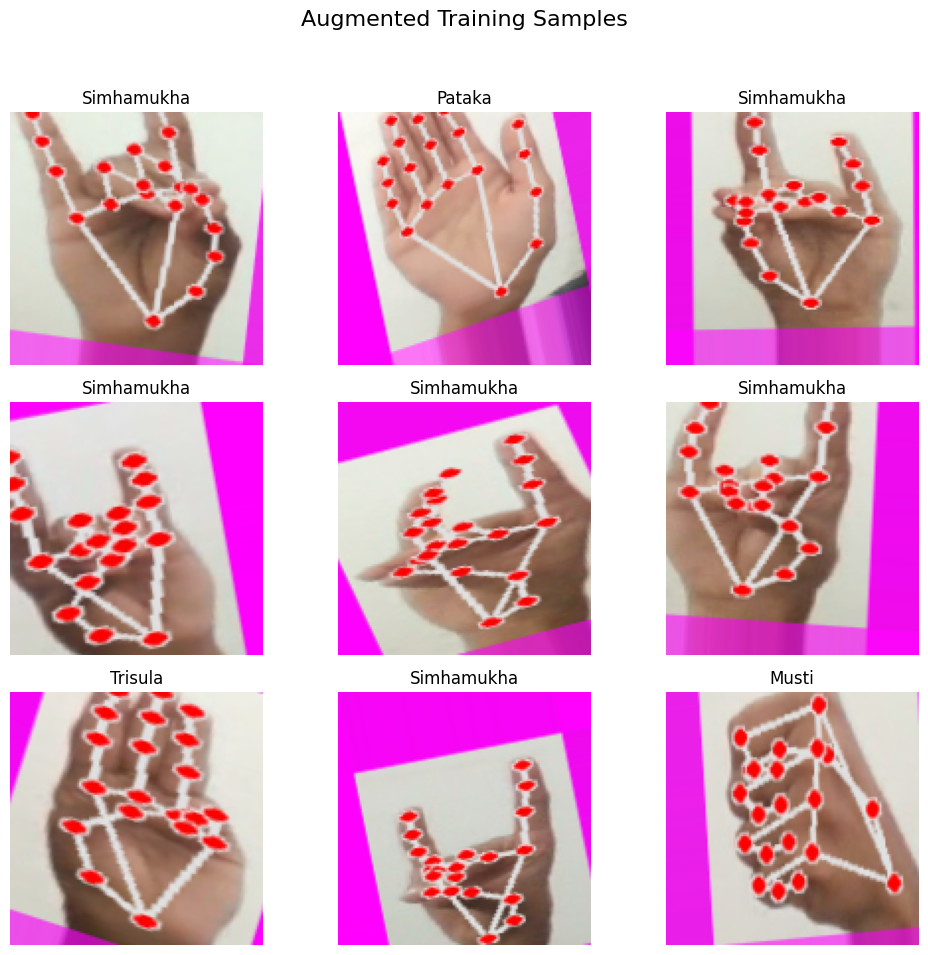

In [47]:
augmented_images, augmented_labels = next(train_generator_augmented)

class_labels = list(train_generator_augmented.class_indices.keys())
predicted_labels = np.argmax(augmented_labels, axis = 1)

plt.figure(figsize = (10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_images[i])
    plt.title(class_labels[predicted_labels[i]])
    plt.axis("off")
plt.suptitle("Augmented Training Samples", fontsize = 16)
plt.tight_layout(rect = [0, 0.03, 1, 0.95])
plt.show()

## CNN DEVELOPMENT : Designing and Training a Custom CNN

In [48]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation = 'relu', input_shape = (IMG_WIDTH, IMG_HEIGHT, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation = 'relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation = 'relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation = 'relu'),
    layers.Dropout(0.5),
    layers.Dense(len(mudra_classes), activation = 'softmax')
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,285 (12.61 MB)

 Trainable params: 3,305,285 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

### Compile and Train the Model

In [49]:
model.compile(
    optimizer = Adam(learning_rate = 0.001),
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

early_stopping = EarlyStopping(monitor = 'val_loss', patience = 10, restore_best_weights = True)
reduce_lr = ReduceLROnPlateau(monitor = 'val_loss', factor = 0.2, patience = 5, min_lr = 0.00001)

history = model.fit(
    train_generator_augmented,
    epochs = 10,
    validation_data = validation_generator,
    callbacks = [early_stopping, reduce_lr]
)

Epoch 1/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 103s 2s/step - accuracy: 0.2579 - loss: 1.6013 - val_accuracy: 0.4567 - val_loss: 1.1063 - learning_rate: 0.0010
Epoch 2/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 121s 2s/step - accuracy: 0.5143 - loss: 1.1687 - val_accuracy: 0.9367 - val_loss: 0.4571 - learning_rate: 0.0010
Epoch 3/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step - accuracy: 0.6257 - loss: 0.8986 - val_accuracy: 0.9667 - val_loss: 0.2637 - learning_rate: 0.0010
Epoch 4/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - accuracy: 0.7350 - loss: 0.6563 - val_accuracy: 0.9667 - val_loss: 0.1761 - learning_rate: 0.0010
Epoch 5/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.7636 - loss: 0.6065 - val_accuracy: 0.9900 - val_loss: 0.1277 - learning_rate: 0.0010
Epoch 6/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - accuracy: 0.7964 - loss: 0.5260 - val_accuracy: 0.9900 - val_loss: 0.0810 - learning_rate: 0.0010
Epoch 7/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.8264 - loss: 0.4750 - val_accuracy

### Plot Training and Validation Curves

In [ ]:
plt.figure(figsize = (12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc = 'upper left')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc = 'upper left')
plt.grid(True)

plt.tight_layout()
plt.show()

## EVALUATION

### Model Evaluation

In [ ]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

In [ ]:
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis = 1)
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names = class_labels))

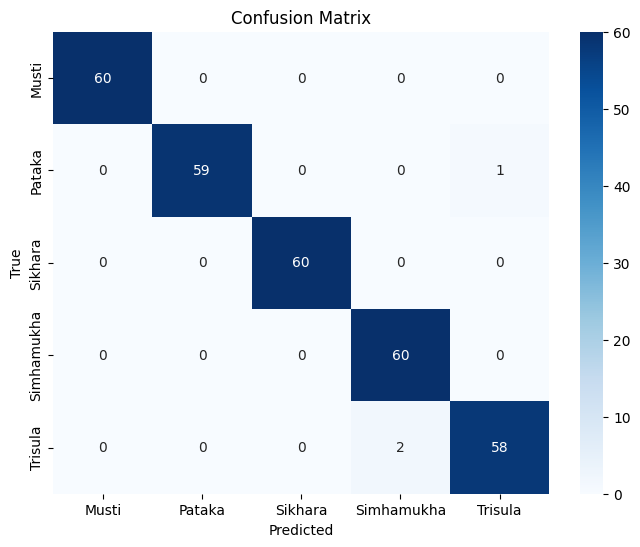

In [52]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize = (8, 6))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues', xticklabels = class_labels, yticklabels = class_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

## Display Misclassified Images

Found 3 misclassified images. Displaying up to 15:


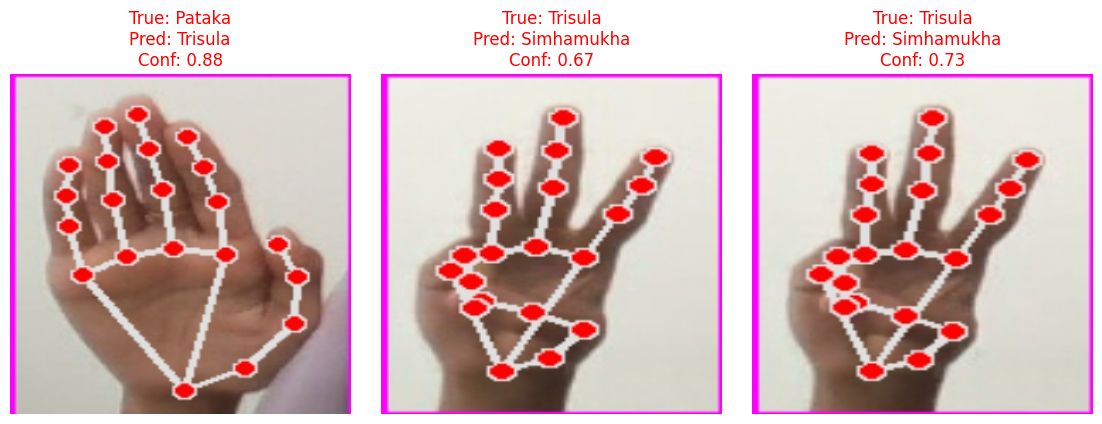

Average confidence for misclassified images: 0.76
Number of high-confidence misclassifications (confidence > 0.8): 1
This indicates the model is confidently wrong, suggesting a strong feature overlap or incorrect labels in the training data for these cases.


In [53]:
misclassified_indices = np.where(y_pred != y_true)[0]

if len(misclassified_indices) == 0:
    print("No misclassified images found.")
else:
    print(f"Found {len(misclassified_indices)} misclassified images. Displaying up to 15:")

    plt.figure(figsize = (15, 15))
    for i, idx in enumerate(misclassified_indices[:15]):
        plt.subplot(4, 4, i + 1)

        img_path = test_df.iloc[idx]['Path']
        img = Image.open(img_path)
        plt.imshow(img)

        true_label = class_labels[y_true[idx]]
        predicted_label = class_labels[y_pred[idx]]
        confidence = y_pred_probs[idx][y_pred[idx]]

        plt.title(f"True: {true_label}\nPred: {predicted_label}\nConf: {confidence:.2f}", color = 'red' if true_label != predicted_label else 'black')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

    misclassified_confidences = [y_pred_probs[idx][y_pred[idx]] for idx in misclassified_indices]
    avg_misclassified_confidence = np.mean(misclassified_confidences)
    print(f"Average confidence for misclassified images: {avg_misclassified_confidence:.2f}")

    high_confidence_misclassifications = [conf for conf in misclassified_confidences if conf > 0.8]
    if len(high_confidence_misclassifications) > 0:
        print(f"Number of high-confidence misclassifications (confidence > 0.8): {len(high_confidence_misclassifications)}")
        print("This indicates the model is confidently wrong, suggesting a strong feature overlap or incorrect labels in the training data for these cases.")
    else:
        print("Most misclassifications are low to moderate confidence, suggesting ambiguity or difficulty in distinguishing these samples.")


## SAVE MODEL

### Save Model, Encoder, and Metadata

In [54]:
model.save('custom_cnn_mudra_model.keras')

class_indices_json = json.dumps(test_generator.class_indices)
with open('class_indices.json', 'w') as f:
    f.write(class_indices_json)

metadata = {
    'IMG_WIDTH': IMG_WIDTH,
    'IMG_HEIGHT': IMG_HEIGHT,
    'mudra_classes': mudra_classes
}
with open('model_metadata.json', 'w') as f:
    json.dump(metadata, f)

print("Model, class indices, and metadata saved successfully.")

Model, class indices, and metadata saved successfully.


## TRANSFER LEARNING

### ResNet50 Comparison

In [55]:
base_model_resnet = ResNet50(weights = 'imagenet', include_top = False, input_shape = (IMG_WIDTH, IMG_HEIGHT, 3))

for layer in base_model_resnet.layers:
    layer.trainable = False

model_resnet = models.Sequential([
    base_model_resnet,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation = 'relu'),
    layers.Dropout(0.5),
    layers.Dense(len(mudra_classes), activation = 'softmax')
])

model_resnet.compile(
    optimizer = Adam(learning_rate = 0.001),
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

model_resnet.summary()

history_resnet = model_resnet.fit(
    train_generator_augmented,
    epochs = 10,
    validation_data = validation_generator,
    callbacks = [early_stopping, reduce_lr]
)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 4, 4, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,629 (90.98 MB)

 Trainable params: 262,917 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 145s 3s/step - accuracy: 0.2457 - loss: 1.6644 - val_accuracy: 0.2733 - val_loss: 1.5037 - learning_rate: 0.0010
Epoch 2/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 127s 3s/step - accuracy: 0.3164 - loss: 1.5397 - val_accuracy: 0.5633 - val_loss: 1.3979 - learning_rate: 0.0010
Epoch 3/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 126s 3s/step - accuracy: 0.3729 - loss: 1.4908 - val_accuracy: 0.4033 - val_loss: 1.3638 - learning_rate: 0.0010
Epoch 4/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 125s 3s/step - accuracy: 0.3879 - loss: 1.4413 - val_accuracy: 0.2467 - val_loss: 1.3962 - learning_rate: 0.0010
Epoch 5/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 125s 3s/step - accuracy: 0.4143 - loss: 1.4101 - val_accuracy: 0.5533 - val_loss: 1.2443 - learning_rate: 0.0010
Epoch 6/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 125s 3s/step - accuracy: 0.4586 - loss: 1.3723 - val_accuracy: 0.4100 - val_loss: 1.2792 - learning_rate: 2.0000e-04
Epoch 7/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 125s 3s/step - accuracy: 0.4736 - loss: 1.3523 - val

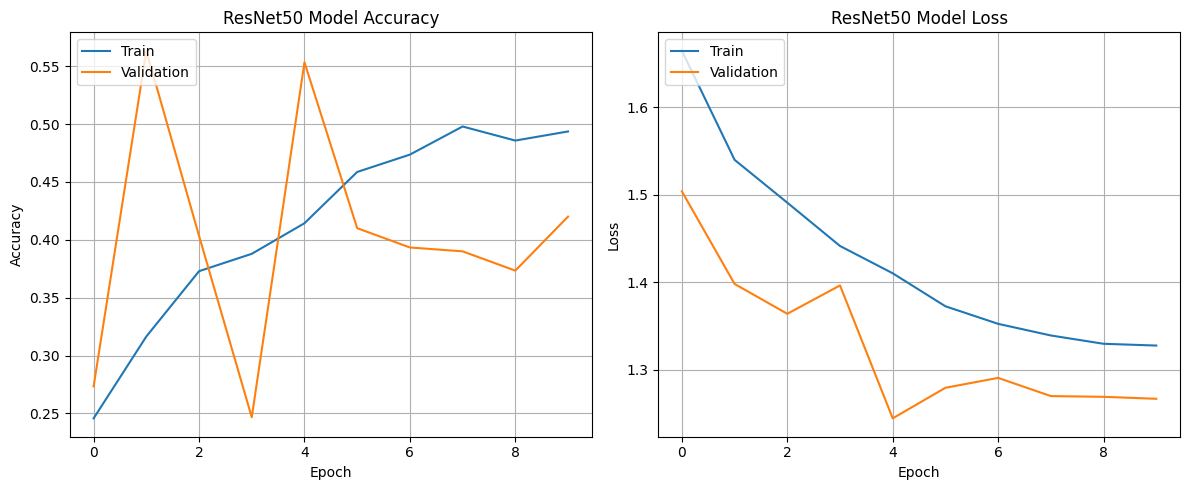

In [56]:
plt.figure(figsize = (12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_resnet.history['accuracy'])
plt.plot(history_resnet.history['val_accuracy'])
plt.title('ResNet50 Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc = 'upper left')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_resnet.history['loss'])
plt.plot(history_resnet.history['val_loss'])
plt.title('ResNet50 Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc = 'upper left')
plt.grid(True)

plt.tight_layout()
plt.show()

In [57]:
test_loss_resnet, test_acc_resnet = model_resnet.evaluate(test_generator)
print(f"ResNet50 Test Accuracy: {test_acc_resnet:.4f}")
print(f"ResNet50 Test Loss: {test_loss_resnet:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.2633 - loss: 1.5069
ResNet50 Test Accuracy: 0.2633
ResNet50 Test Loss: 1.5069


### Comparison with Custom CNN

In [58]:
print("Comparison Table:")

# Ensure 'duration' key exists, if not, handle it gracefully (e.g., by logging or setting to NaN)
custom_cnn_training_time_per_epoch = np.mean(history.history.get('duration', [np.nan]))
resnet_training_time_per_epoch = np.mean(history_resnet.history.get('duration', [np.nan]))

comparison_data = {
    'Model': ['Custom CNN', 'ResNet50 (Transfer Learning)'],
    'Test Accuracy': [test_acc, test_acc_resnet],
    'Model Size (MB)': [model.count_params() * 4 / (1024*1024), model_resnet.count_params() * 4 / (1024*1024)], # Assuming float32
    'Training Time (approx s/epoch)': [custom_cnn_training_time_per_epoch, resnet_training_time_per_epoch]
}

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

Comparison Table:


,Model,Test Accuracy,Model Size (MB),Training Time (approx s/epoch)
0,Custom CNN,0.990000,12.608662,NaN
1,ResNet50 (Transfer Learning),0.263333,90.982929,NaN


In [28]:
X = data_df['Path']
y = data_df['Label']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size = 0.3, random_state = 42, stratify = y)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size = 0.5, random_state = 42, stratify = y_temp)

train_df = pd.DataFrame({'Path': X_train, 'Label': y_train})
val_df = pd.DataFrame({'Path': X_val, 'Label': y_val})
test_df = pd.DataFrame({'Path': X_test, 'Label': y_test})

print("Dataset split complete:")
print(f"Training set size: {len(train_df)}")
print(f"Validation set size: {len(val_df)}")
print(f"Test set size: {len(test_df)}")

print("Training set class distribution:")
display(train_df['Label'].value_counts().sort_index().to_frame())

print("Validation set class distribution:")
display(val_df['Label'].value_counts().sort_index().to_frame())

print("Test set class distribution:")
display(test_df['Label'].value_counts().sort_index().to_frame())

Dataset split complete:
Training set size: 1400
Validation set size: 300
Test set size: 300
Training set class distribution:


,count
Label,
Musti,280
Pataka,280
Sikhara,280
Simhamukha,280
Trisula,280


Validation set class distribution:


,count
Label,
Musti,60
Pataka,60
Sikhara,60
Simhamukha,60
Trisula,60


Test set class distribution:


,count
Label,
Musti,60
Pataka,60
Sikhara,60
Simhamukha,60
Trisula,60


In [59]:
train_datagen = ImageDataGenerator(rescale = 1./255)
val_datagen = ImageDataGenerator(rescale = 1./255)
test_datagen = ImageDataGenerator(rescale = 1./255)

train_generator = train_datagen.flow_from_dataframe(
    dataframe = train_df,
    x_col = 'Path',
    y_col = 'Label',
    target_size = (IMG_WIDTH, IMG_HEIGHT),
    batch_size = BATCH_SIZE,
    class_mode = 'categorical',
    shuffle = True,
    seed = 42
)

validation_generator = val_datagen.flow_from_dataframe(
    dataframe = val_df,
    x_col = 'Path',
    y_col = 'Label',
    target_size = (IMG_WIDTH, IMG_HEIGHT),
    batch_size = BATCH_SIZE,
    class_mode = 'categorical',
    shuffle = False,
    seed = 42
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe = test_df,
    x_col = 'Path',
    y_col = 'Label',
    target_size = (IMG_WIDTH, IMG_HEIGHT),
    batch_size = BATCH_SIZE,
    class_mode = 'categorical',
    shuffle = False,
    seed = 42
)

print(f"Train generator found {train_generator.samples} images belonging to {len(train_generator.class_indices)} classes.")
print(f"Validation generator found {validation_generator.samples} images belonging to {len(validation_generator.class_indices)} classes.")
print(f"Test generator found {test_generator.samples} images belonging to {len(test_generator.class_indices)} classes.")

Found 1400 validated image filenames belonging to 5 classes.
Found 300 validated image filenames belonging to 5 classes.
Found 300 validated image filenames belonging to 5 classes.
Train generator found 1400 images belonging to 5 classes.
Validation generator found 300 images belonging to 5 classes.
Test generator found 300 images belonging to 5 classes.


## PREPROCESSING & AUGMENTATION

In [24]:
print(f"Re-initializing image data generators with augmentation for training data...")

# Augmentation for training data
train_datagen_augmented = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Only rescaling for validation and test data (no augmentation)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator_augmented = train_datagen_augmented.flow_from_dataframe(
    dataframe=train_df,
    x_col='Path',
    y_col='Label',
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

validation_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='Path',
    y_col='Label',
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=42
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='Path',
    y_col='Label',
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=42
)

print(f"Train generator (augmented) found {train_generator_augmented.samples} images belonging to {len(train_generator_augmented.class_indices)} classes.")
print(f"Validation generator found {validation_generator.samples} images belonging to {len(validation_generator.class_indices)} classes.")
print(f"Test generator found {test_generator.samples} images belonging to {len(test_generator.class_indices)} classes.")

Re-initializing image data generators with augmentation for training data...
Found 1400 validated image filenames belonging to 5 classes.
Found 300 validated image filenames belonging to 5 classes.
Found 300 validated image filenames belonging to 5 classes.
Train generator (augmented) found 1400 images belonging to 5 classes.
Validation generator found 300 images belonging to 5 classes.
Test generator found 300 images belonging to 5 classes.


### Visualizing Augmented Samples

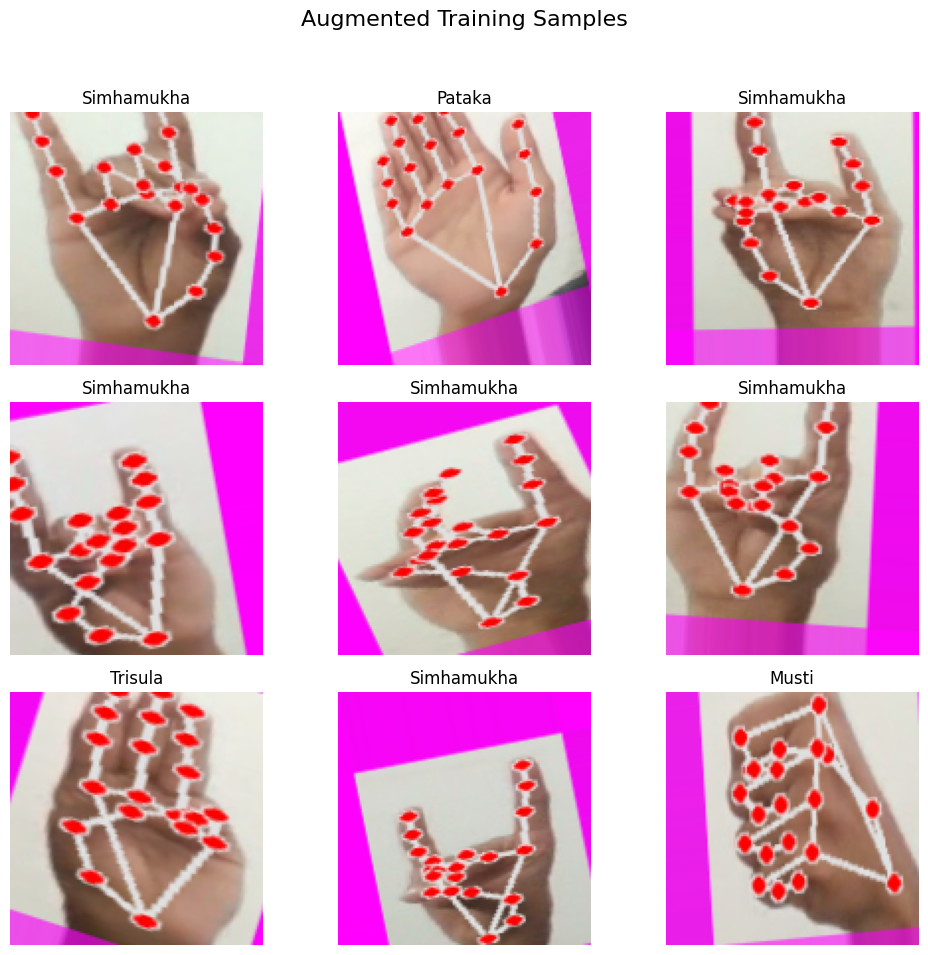

In [23]:
augmented_images, augmented_labels = next(train_generator_augmented)    # Batch/Chunk of images + labels from the augmented training generator

# Convert one-hot encoded labels back to class names
class_labels = list(train_generator_augmented.class_indices.keys())
predicted_labels = np.argmax(augmented_labels, axis=1)

plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_images[i])
    plt.title(class_labels[predicted_labels[i]])
    plt.axis("off")
plt.suptitle("Augmented Training Samples", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])   # AdjustED layout to prevent subtitle overlap
plt.show()

## CNN DEVELOPMENT

### Design and Train a Custom CNN

In [25]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_WIDTH, IMG_HEIGHT, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Added dropout for REGULARIZATION
    layers.Dense(len(mudra_classes), activation='softmax') # Output layer =  5 classes
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,285 (12.61 MB)

 Trainable params: 3,305,285 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

### Compile and Train the Model

In [27]:
model.compile(
    optimizer = Adam(learning_rate=0.001),
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

# Callbacks for hyperparameter tuning and to prevent overfitting
early_stopping = EarlyStopping(monitor = 'val_loss', patience = 10, restore_best_weights = True)
reduce_lr = ReduceLROnPlateau(monitor = 'val_loss', factor = 0.2, patience = 5, min_lr = 0.00001)

history = model.fit(
    train_generator_augmented,
    epochs = 10,
    validation_data = validation_generator,
    callbacks = [early_stopping, reduce_lr]
)

Epoch 1/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 443s 10s/step - accuracy: 0.3571 - loss: 1.4864 - val_accuracy: 0.6367 - val_loss: 0.8955 - learning_rate: 0.0010
Epoch 2/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.5229 - loss: 1.1561 - val_accuracy: 0.8767 - val_loss: 0.4488 - learning_rate: 0.0010
Epoch 3/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.6543 - loss: 0.8518 - val_accuracy: 0.9733 - val_loss: 0.1623 - learning_rate: 0.0010
Epoch 4/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.7571 - loss: 0.6327 - val_accuracy: 0.9900 - val_loss: 0.1064 - learning_rate: 0.0010
Epoch 5/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 72s 2s/step - accuracy: 0.7664 - loss: 0.5780 - val_accuracy: 0.9800 - val_loss: 0.0855 - learning_rate: 0.0010
Epoch 6/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 71s 2s/step - accuracy: 0.7879 - loss: 0.5567 - val_accuracy: 0.9900 - val_loss: 0.0793 - learning_rate: 0.0010
Epoch 7/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 71s 2s/step - accuracy: 0.8186 - loss: 0.4438 - val_accuracy

### Plot Training and Validation Curves

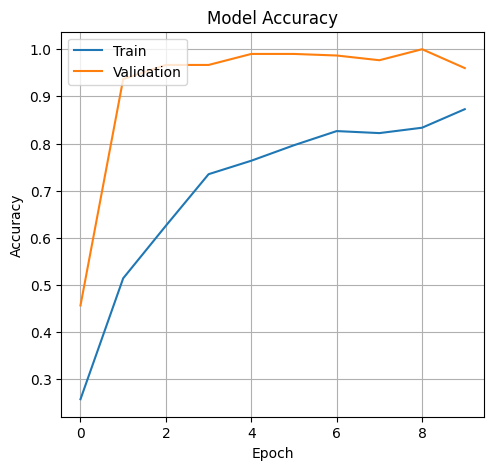

In [50]:
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)

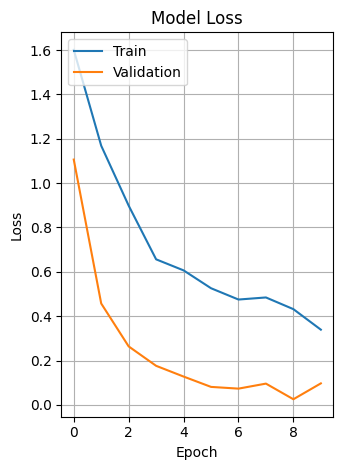

In [51]:
# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.show()

## EVALUATION

In [30]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 105s 12s/step - accuracy: 0.9900 - loss: 0.0491
Test Accuracy: 0.9900
Test Loss: 0.0491


In [34]:
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis = 1)
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names = class_labels))

10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 603ms/step
Classification Report:
              precision    recall  f1-score   support

       Musti       1.00      1.00      1.00        60
      Pataka       1.00      0.98      0.99        60
     Sikhara       1.00      1.00      1.00        60
  Simhamukha       0.97      1.00      0.98        60
     Trisula       0.98      0.97      0.97        60

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



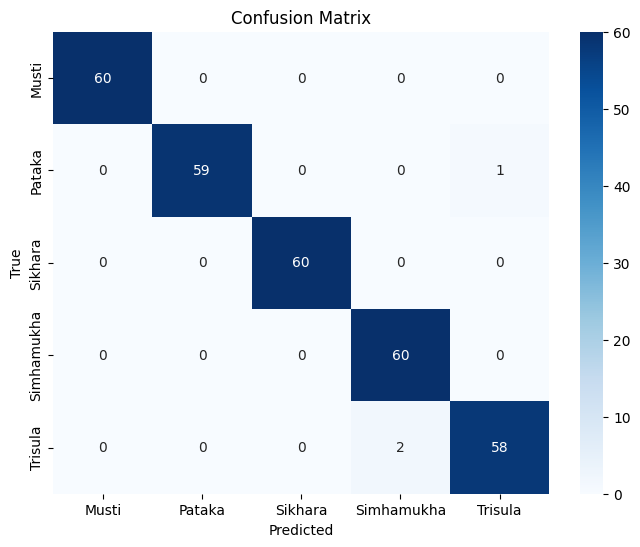

In [35]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize = (8, 6))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues', xticklabels = class_labels, yticklabels = class_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

## Misclassified Images

Found 3 misclassified images. Displaying up to 15:


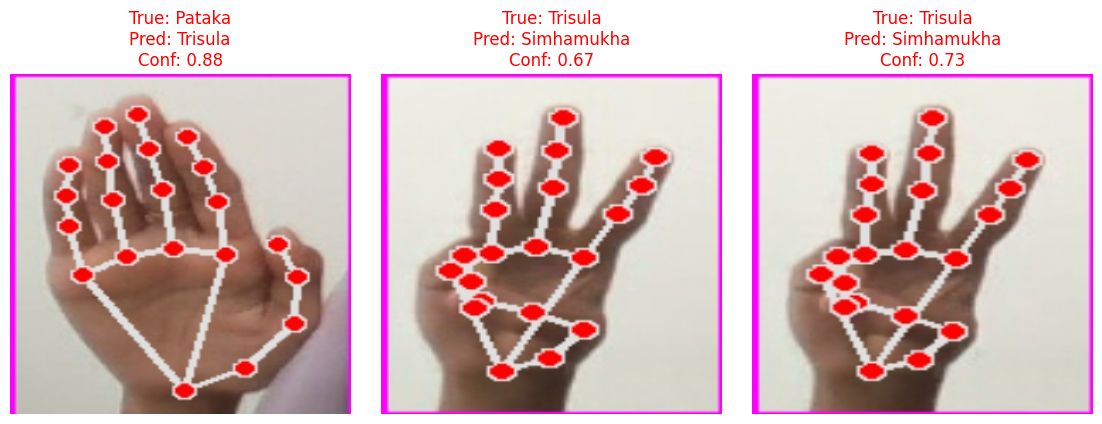

Average confidence for misclassified images: 0.76
Number of high-confidence misclassifications (confidence > 0.8): 1
This indicates the model is confidently wrong, suggesting a strong feature overlap or incorrect labels in the training data for these cases.


In [36]:
misclassified_indices = np.where(y_pred != y_true)[0]

if len(misclassified_indices) == 0:
    print("No misclassified images found.")
else:
    print(f"Found {len(misclassified_indices)} misclassified images. Displaying up to 15:")

    plt.figure(figsize = (15, 15))
    for i, idx in enumerate(misclassified_indices[:15]):
        plt.subplot(4, 4, i + 1)

        img_path = test_df.iloc[idx]['Path']
        img = Image.open(img_path)
        plt.imshow(img)

        true_label = class_labels[y_true[idx]]
        predicted_label = class_labels[y_pred[idx]]
        confidence = y_pred_probs[idx][y_pred[idx]]

        plt.title(f"True: {true_label}\nPred: {predicted_label}\nConf: {confidence:.2f}", color = 'red' if true_label != predicted_label else 'black')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

    # Analyze confidence scores for misclassified images
    misclassified_confidences = [y_pred_probs[idx][y_pred[idx]] for idx in misclassified_indices]
    avg_misclassified_confidence = np.mean(misclassified_confidences)
    print(f"Average confidence for misclassified images: {avg_misclassified_confidence:.2f}")

    high_confidence_misclassifications = [conf for conf in misclassified_confidences if conf > 0.8]
    if len(high_confidence_misclassifications) > 0:
        print(f"Number of high-confidence misclassifications (confidence > 0.8): {len(high_confidence_misclassifications)}")
        print("Indicates the model is wrong, suggesting a strong feature overlap or incorrect labels in the training data for these cases.")
    else:
        print("Most misclassifications are low to moderate confidence, suggesting ambiguity or difficulty in distinguishing these samples.")


## SAVE MODEL

### Save Model, Encoder, and Metadata

In [37]:
model.save('custom_cnn_mudra_model.keras')

class_indices_json = json.dumps(test_generator.class_indices)
with open('class_indices.json', 'w') as f:
    f.write(class_indices_json)

metadata = {
    'IMG_WIDTH': IMG_WIDTH,
    'IMG_HEIGHT': IMG_HEIGHT,
    'mudra_classes': mudra_classes
}
with open('model_metadata.json', 'w') as f:
    json.dump(metadata, f)

print("Model, class indices, and metadata saved successfully.")

Model, class indices, and metadata saved successfully.


## TRANSFER LEARNING

### ResNet50 Comparison

In [33]:
base_model_resnet = ResNet50(weights = 'imagenet', include_top = False, input_shape = (IMG_WIDTH, IMG_HEIGHT, 3))

for layer in base_model_resnet.layers:
    layer.trainable = False

model_resnet = models.Sequential([
    base_model_resnet,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation = 'relu'),
    layers.Dropout(0.5),
    layers.Dense(len(mudra_classes), activation = 'softmax')
])

model_resnet.compile(
    optimizer = Adam(learning_rate = 0.001),
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

model_resnet.summary()

history_resnet = model_resnet.fit(
    train_generator_augmented,
    epochs = 10, # Keeping epochs consistent for comparison
    validation_data = validation_generator,
    callbacks = [early_stopping, reduce_lr]
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 4, 4, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,629 (90.98 MB)

 Trainable params: 262,917 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 153s 3s/step - accuracy: 0.2400 - loss: 1.6403 - val_accuracy: 0.4800 - val_loss: 1.5309 - learning_rate: 0.0010
Epoch 2/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 134s 3s/step - accuracy: 0.2986 - loss: 1.5483 - val_accuracy: 0.3600 - val_loss: 1.4497 - learning_rate: 0.0010
Epoch 3/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 135s 3s/step - accuracy: 0.3264 - loss: 1.5064 - val_accuracy: 0.2100 - val_loss: 1.4795 - learning_rate: 0.0010
Epoch 4/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 131s 3s/step - accuracy: 0.3636 - loss: 1.4592 - val_accuracy: 0.3967 - val_loss: 1.3224 - learning_rate: 0.0010
Epoch 5/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 140s 3s/step - accuracy: 0.4229 - loss: 1.4007 - val_accuracy: 0.2633 - val_loss: 1.4593 - learning_rate: 0.0010
Epoch 6/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 126s 3s/step - accuracy: 0.4236 - loss: 1.3820 - val_accuracy: 0.4433 - val_loss: 1.2786 - learning_rate: 2.0000e-04
Epoch 7/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 128s 3s/step - accuracy: 0.4750 - loss: 1.3539 - val

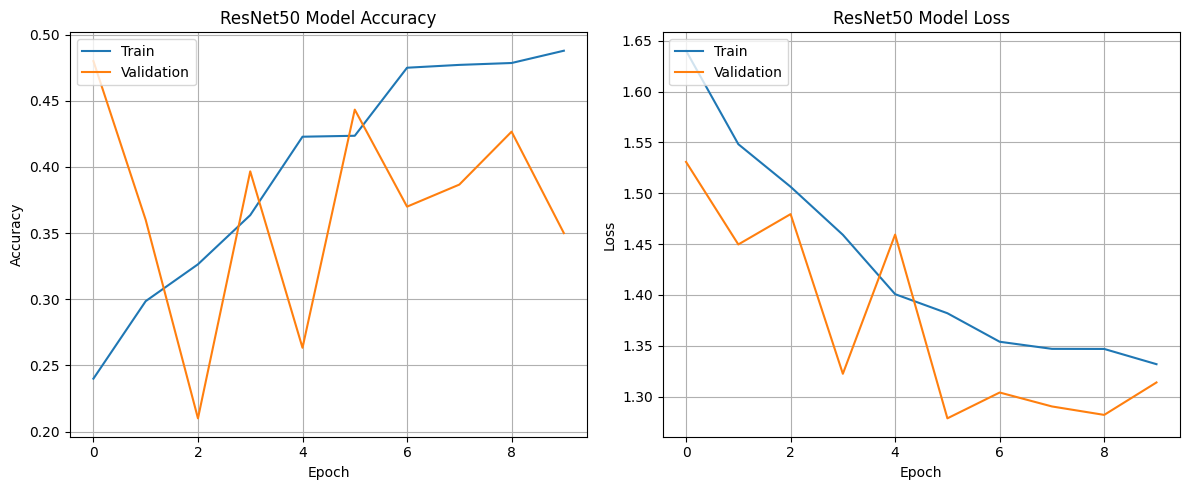

In [38]:
plt.figure(figsize = (12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_resnet.history['accuracy'])
plt.plot(history_resnet.history['val_accuracy'])
plt.title('ResNet50 Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc = 'upper left')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_resnet.history['loss'])
plt.plot(history_resnet.history['val_loss'])
plt.title('ResNet50 Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc = 'upper left')
plt.grid(True)

plt.tight_layout()
plt.show()

In [39]:
test_loss_resnet, test_acc_resnet = model_resnet.evaluate(test_generator)
print(f"ResNet50 Test Accuracy: {test_acc_resnet:.4f}")
print(f"ResNet50 Test Loss: {test_loss_resnet:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.4900 - loss: 1.5338
ResNet50 Test Accuracy: 0.4900
ResNet50 Test Loss: 1.5338


### Comparison with Custom CNN

In [60]:
print("Comparison Table:")

# Ensure 'duration' key exists, if not, handle it gracefully (e.g., by logging or setting to NaN)
custom_cnn_training_time_per_epoch = np.mean(history.history.get('duration', [np.nan]))
resnet_training_time_per_epoch = np.mean(history_resnet.history.get('duration', [np.nan]))

comparison_data = {
    'Model': ['Custom CNN', 'ResNet50 (Transfer Learning)'],
    'Test Accuracy': [test_acc, test_acc_resnet],
    'Model Size (MB)': [model.count_params() * 4 / (1024*1024), model_resnet.count_params() * 4 / (1024*1024)], # Assuming float32
    'Training Time (approx s/epoch)': [custom_cnn_training_time_per_epoch, resnet_training_time_per_epoch]
}

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

Comparison Table:


,Model,Test Accuracy,Model Size (MB),Training Time (approx s/epoch)
0,Custom CNN,0.990000,12.608662,NaN
1,ResNet50 (Transfer Learning),0.263333,90.982929,NaN
